# IBM Stock Data Preprocessing

This notebook takes the raw IBM stock data and prepares it for the RNN/LSTM/GRU models. It runs through cleaning, feature engineering, splitting by year, scaling, and turning the data into sequences ready for training.

All the actual logic lives in `src/data_preprocessing.py`, this notebook just calls the functions and inspects the output.

In [12]:
# path setup so we can import from src
import os
import sys
sys.path.append(os.path.abspath('..'))

import matplotlib.pyplot as plt
import seaborn as sns
from src.data_preprocessing import preprocess_pipeline, prepare_model_data
from src.utils import load_data

## Load the raw data

In [13]:
df = load_data("../data/raw/ibm_stock_1980_2025.csv")
df

,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Adj Factor
Date,,,,,,,,,,
1980-01-02,1980-01-02,15.057361,15.415870,14.937859,14.937859,0.965845,"1,723,808",0.0,0.0,0.064657
1980-01-03,1980-01-03,14.937859,15.176864,14.639101,15.176864,0.981298,"2,553,495",0.0,0.0,0.064657
1980-01-04,1980-01-04,15.176864,15.236616,15.057361,15.146989,0.979366,"1,978,195",0.0,0.0,0.064657
1980-01-07,1980-01-07,15.146989,15.146989,14.967734,15.087237,0.975503,"1,480,718",0.0,0.0,0.064657
1980-01-08,1980-01-08,15.087237,16.132887,14.967734,16.103010,1.041180,"2,968,130",0.0,0.0,0.064657
...,...,...,...,...,...,...,...,...,...,...
2025-07-24,2025-07-24,261.250000,262.049988,252.750000,260.510010,260.510010,"22,647,700",0.0,0.0,1.000000
2025-07-25,2025-07-25,260.019989,260.799988,256.350006,259.720001,259.720001,"7,758,700",0.0,0.0,1.000000
2025-07-28,2025-07-28,260.299988,264.000000,259.609985,263.209991,263.209991,"5,192,500",0.0,0.0,1.000000


## Run the preprocessing pipeline

This single function handles everything in order:
- removes duplicate dates
- fixes the Volume column (string with commas to float)
- removes rows with negative or zero prices
- removes rows with invalid OHLC (High/Low logic errors)
- adds the engineered features (Daily Return, Volatility, High Low Range, Open Close Range)
- removes extreme return outliers
- saves the cleaned data to `data/processed/`

Each step prints what it found and removed, so if nothing needs cleaning it will say so instead of just running silently.

In [14]:
df = preprocess_pipeline(df, '../data/processed')

negative or zero price rows: 0
no negative or zero price rows found
invalid OHLC rows: 0
no invalid OHLC rows found
First 5 NaN Values Removed Cause the volatility
Feature Engineered Successfully, Columns Before: 10, Columns After: 9
return outlier rows found: 1, Removed Successfully!
rows before: 11488, rows after: 11482, total removed: 6


## Quick look at the processed data

In [15]:
df.head(10)

,Open,High,Low,Close,Volume,Volatility,Open Close Range,High Low Range
Date,,,,,,,,
1980-01-09,16.103010,16.252390,15.625000,15.625000,3380672.0,0.036173,0.478010,0.627390
1980-01-10,15.774379,16.192638,15.774379,16.132887,2219194.0,0.037633,0.358508,0.418260
1980-01-11,16.132887,16.312141,15.684751,16.013384,2280280.0,0.038242,0.119503,0.627391
1980-01-14,16.013384,16.073135,15.834130,15.983509,1663977.0,0.038039,0.029875,0.239005
1980-01-15,15.983509,16.790154,15.893881,16.760277,3922500.0,0.031633,0.776768,0.896273
1980-01-16,16.760277,16.939531,16.670650,16.730402,6284368.0,0.024993,0.029875,0.268881
1980-01-17,16.730402,16.820028,16.551147,16.551147,2564792.0,0.024465,0.179255,0.268881
1980-01-18,16.551147,16.670650,16.401770,16.640774,2732570.0,0.023442,0.089626,0.268881
1980-01-21,16.640774,16.700525,16.491396,16.491396,1557285.0,0.024382,0.149378,0.209129


In [16]:
df.tail(10)

,Open,High,Low,Close,Volume,Volatility,Open Close Range,High Low Range
Date,,,,,,,,
2025-07-17,281.500000,283.459991,280.899994,282.000000,3337200.0,0.005689,0.500000,2.559998
2025-07-18,283.380005,287.160004,282.220001,285.869995,4478200.0,0.007038,2.489990,4.940002
2025-07-21,286.290009,287.730011,284.380005,284.709991,3051800.0,0.007500,1.580017,3.350006
2025-07-22,284.739990,284.880005,281.250000,281.959991,4824200.0,0.008726,2.779999,3.630005
2025-07-23,284.299988,288.079987,281.440002,282.010010,8105900.0,0.008634,2.289978,6.639984
2025-07-24,261.250000,262.049988,252.750000,260.510010,22647700.0,0.035191,0.739990,9.299988
2025-07-25,260.019989,260.799988,256.350006,259.720001,7758700.0,0.032437,0.299988,4.449982
2025-07-28,260.299988,264.000000,259.609985,263.209991,5192500.0,0.035217,2.910004,4.390015
2025-07-29,264.299988,265.799988,261.019989,262.410004,4627300.0,0.035593,1.889984,4.779999


## Split, scale, and create sequences

`prepare_model_data` does the full remaining pipeline:
- splits the data into train/valid/test by year
- scales everything with MinMaxScaler (fit only on train, to avoid leakage)
- builds the sliding window sequences (timesteps) for the RNN models
- reshapes into the (samples, timesteps, features) shape Keras expects
- saves all splits into one pickle file for reuse

Train covers up to 2022, valid is 2023 to 2024, test is 2025. Timesteps is set to 90 days per sequence.

In [17]:
X_train, y_train, X_valid, y_valid, X_test, y_test = prepare_model_data(data=df,
                                                                        year_splits=[2022, 2024, 2025],
                                                                        timesteps=90, 
                                                                        num_features=len(df.columns), save_dir='../data/processed')

Splitted Successfully to train/valid/test splits!
Normalization Transfromed Successfully!
Sequences Created Successfully, Sequences Counts: 10747
Sequences Created Successfully, Sequences Counts: 502
Sequences Created Successfully, Sequences Counts: 143
Scaler & All data successfully saved in a single file!


## Check the shapes
Makes sure the sequence shapes look right before moving to modeling.

In [18]:
X_train.shape

(10747, 90, 8)

In [19]:
X_valid.shape

(502, 90, 8)

In [20]:
X_test.shape

(143, 90, 8)

## Correlation after feature engineering
See how the new features (Daily Return, Volatility, ranges) relate to price and to each other.

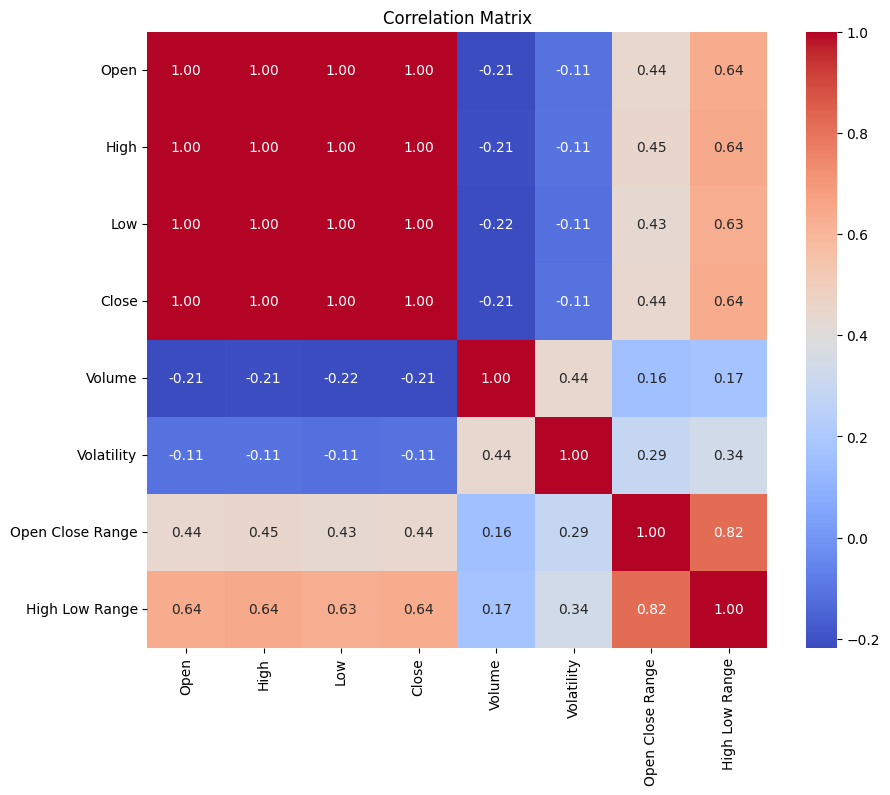

In [21]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## Outliers check after cleaning
Boxplots on the final processed columns, just to confirm the cleaning worked as expected.

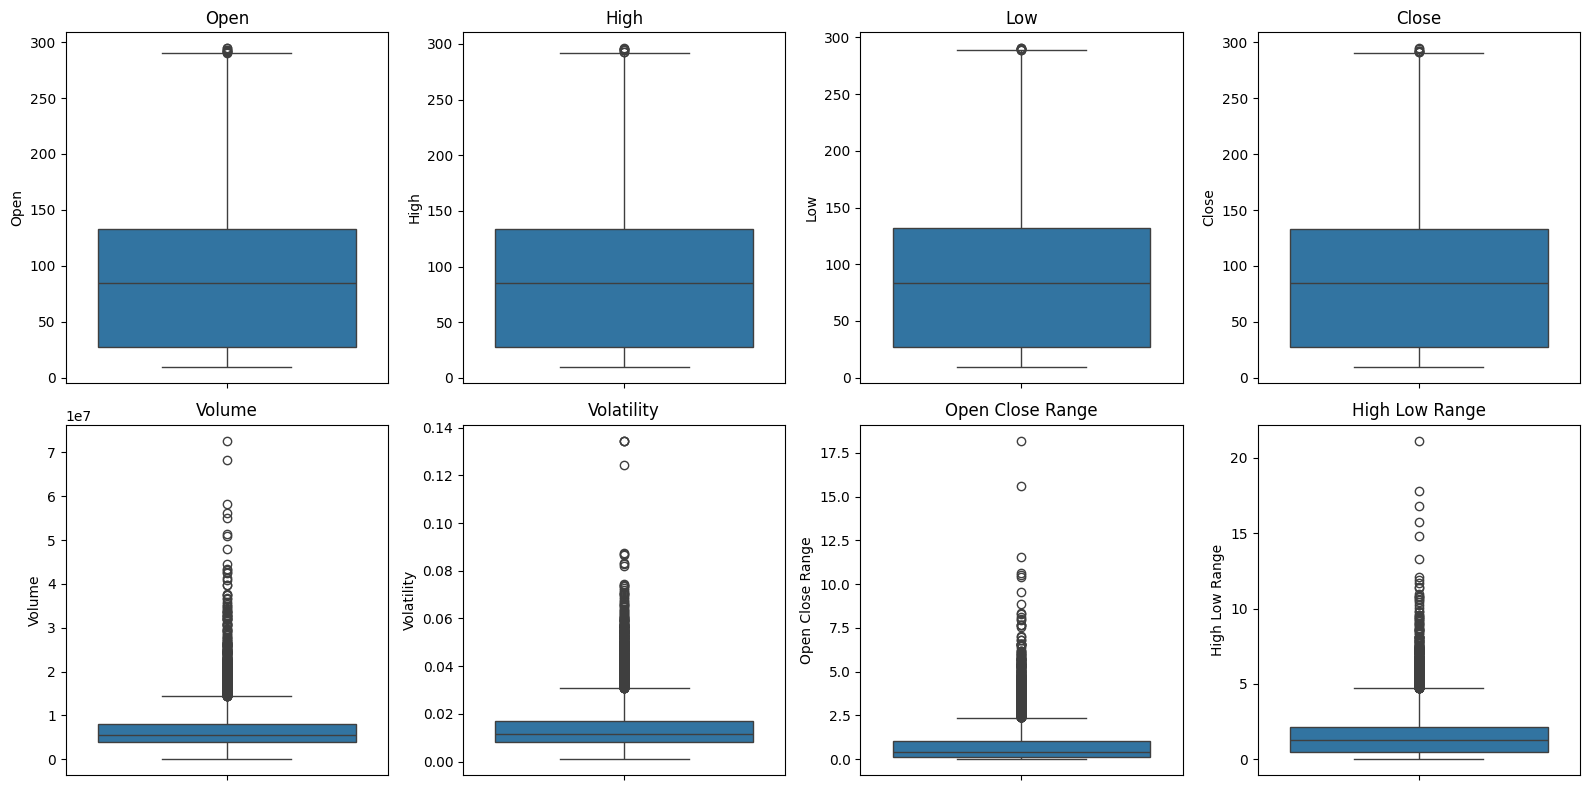

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
cols_to_plot = df.columns

for ax, col in zip(axes.flatten(), cols_to_plot):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()